# Transfer Learning with ResNet50 on Flowers102
## Deep Learning Assignment — 6 Freezing Experiments

| Exp | Strategy | Description |
|-----|----------|-------------|
| A | Total Freeze (Eval) | Pretrained features, no training |
| B | Feature Extraction | Freeze backbone, train head only |
| C | Partial Unfreeze | Freeze layer1-3, train layer4 + head |
| D | Fine-Tune | Freeze layer1-2, train layer3-4 + head |
| E | Full Unfreeze | Train all layers, very low LR |
| F | Gradual Unfreeze | Phase-by-phase unfreezing (ULMFiT style) |

**Model:** ResNet50 - ImageNet pretrained
**Dataset:** Oxford Flowers102  



## Step 1 — Install

In [1]:
!pip install tensorflow tensorflow-datasets scikit-learn seaborn -q

## Step 2 — Imports

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import mixed_precision
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Enable mixed precision — uses float16 on GPU, ~2x speedup
mixed_precision.set_global_policy('mixed_float16')

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU'))
print("Precision  :", mixed_precision.global_policy().name)


TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Precision  : mixed_float16


## Step 3 — Config

In [3]:
IMG_SIZE    = 128    # 224→128: ~3x faster, ResNet50 works fine at 128
BATCH_SIZE  = 64     # larger batch = better GPU use
NUM_CLASSES = 102
AUTOTUNE    = tf.data.AUTOTUNE

# Epochs — early stopping handles actual cutoff
MAX_EPOCHS   = 50    # A-E
PHASE_EPOCHS = 20    # F: per phase (↑ from 10 — more time to converge per phase)
ES_PATIENCE  = 10    # patience for early stopping

MEAN = tf.constant([0.485, 0.456, 0.406])
STD  = tf.constant([0.229, 0.224, 0.225])

print("Config ready!")
print(f"  IMG_SIZE   : {IMG_SIZE}x{IMG_SIZE}  (3x faster than 224x224)")
print(f"  BATCH_SIZE : {BATCH_SIZE}")
print(f"  MAX_EPOCHS : {MAX_EPOCHS}  (early stopping patience={ES_PATIENCE})")
print(f"  PHASE_EPOCHS: {PHASE_EPOCHS}  (Exp F per-phase budget)")


Config ready!
  IMG_SIZE   : 128x128  (3x faster than 224x224)
  BATCH_SIZE : 64
  MAX_EPOCHS : 50  (early stopping patience=10)
  PHASE_EPOCHS: 20  (Exp F per-phase budget)


## Step 4 — Load Flowers102

In [4]:
(ds_train, ds_val, ds_test), info = tfds.load(
    'oxford_flowers102',
    split=['train', 'validation', 'test'],
    as_supervised=True, with_info=True
)

print("Flowers102 loaded!")
print(f"  Train : {info.splits['train'].num_examples}")
print(f"  Val   : {info.splits['validation'].num_examples}")
print(f"  Test  : {info.splits['test'].num_examples}")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.MANKKD_2.1.1/oxford_flowers102-test.tfrecord*…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.MANKKD_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.
Flowers102 loaded!
  Train : 1020
  Val   : 1020
  Test  : 6149


## Step 5 — Preprocessing Pipeline

In [5]:
def preprocess(image, label, augment=False):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    if augment:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_flip_up_down(image)
        image = tf.image.random_brightness(image, 0.3)
        image = tf.image.random_contrast(image, 0.7, 1.3)
        image = tf.image.random_saturation(image, 0.7, 1.3)
        image = tf.image.random_hue(image, 0.1)
        # random crop for slight zoom/rotation effect
        image = tf.image.resize(image, [int(IMG_SIZE*1.15), int(IMG_SIZE*1.15)])
        image = tf.image.random_crop(image, [IMG_SIZE, IMG_SIZE, 3])
    image = (image - MEAN) / STD
    return image, label

# NO merge — val stays clean for honest monitoring
train_ds = (ds_train
    .map(lambda x,y: preprocess(x,y,augment=True), num_parallel_calls=AUTOTUNE)
    .shuffle(1024).batch(BATCH_SIZE).prefetch(AUTOTUNE))

val_ds = (ds_val
    .map(lambda x,y: preprocess(x,y), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(AUTOTUNE))

test_ds = (ds_test
    .map(lambda x,y: preprocess(x,y), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(AUTOTUNE))

print("Pipelines ready!")
print(f"  train_ds : original train only ({info.splits['train'].num_examples} samples)")
print(f"  val_ds   : original val — clean, no leakage")
print(f"  Augmentation : flip LR+UD, brightness, contrast, saturation, hue, random crop")

Pipelines ready!
  train_ds : original train only (1020 samples)
  val_ds   : original val — clean, no leakage
  Augmentation : flip LR+UD, brightness, contrast, saturation, hue, random crop


## Step 6 — Sample Images

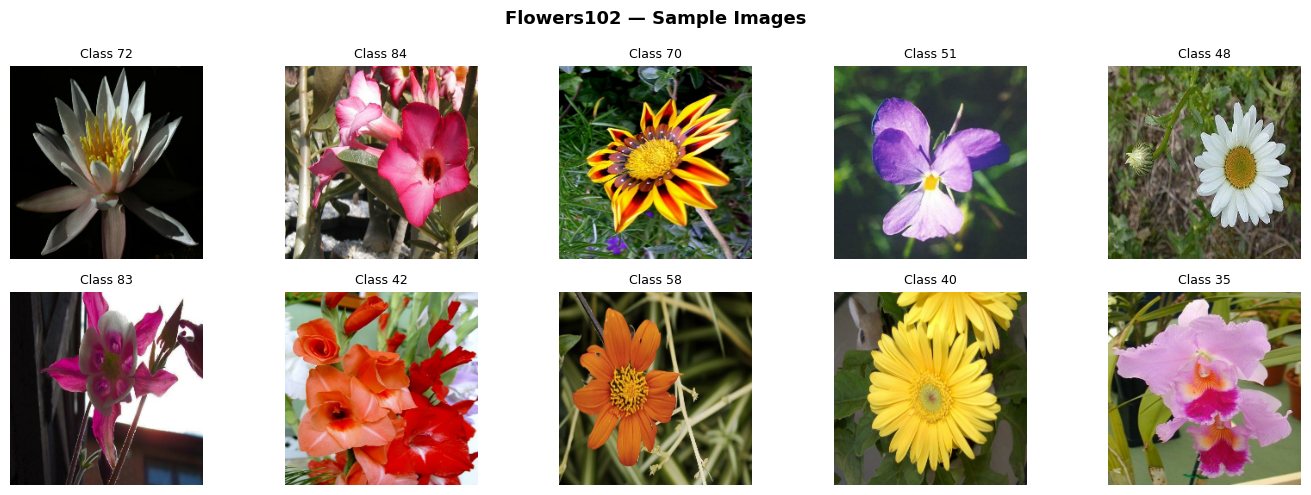

In [6]:
# Resize before batch — Flowers102 images have variable sizes
sample_ds = (ds_train
    .map(lambda x,y: (tf.image.resize(x,[224,224]), y))
    .batch(10).take(1))

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
fig.suptitle("Flowers102 — Sample Images", fontsize=13, fontweight='bold')
for imgs, labels in sample_ds:
    for i, ax in enumerate(axes.flat):
        ax.imshow(tf.cast(imgs[i], tf.uint8).numpy())
        ax.set_title(f"Class {labels[i].numpy()}", fontsize=9)
        ax.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()


## Step 7 — Build Model

In [7]:
def build_model():
    """ResNet50 (ImageNet) + lightweight head. Backbone starts frozen."""
    base = ResNet50(weights='imagenet', include_top=False,
                   input_shape=(IMG_SIZE, IMG_SIZE, 3))

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.2)(x)   # ↓ from 0.4 — less regularisation needed with more data
    # float32 output — required when using mixed precision
    output = Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

    model = Model(inputs=base.input, outputs=output)
    return model, base


def count_params(model):
    total     = model.count_params()
    trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f"  Trainable : {trainable:>10,}  ({100*trainable/total:.1f}%)")
    print(f"  Frozen    : {total-trainable:>10,}  ({100*(total-trainable)/total:.1f}%)")

print("Model builder ready!  (Dropout=0.2)")


Model builder ready!  (Dropout=0.2)


## Step 8 — Callbacks

In [8]:
def get_callbacks(patience=ES_PATIENCE):
    """EarlyStopping + ReduceLROnPlateau — for Exp B/C/D."""
    return [
        EarlyStopping(monitor='val_accuracy', patience=patience,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1)
    ]


def get_callbacks_no_rlr(patience=ES_PATIENCE):
    """EarlyStopping only — NO ReduceLROnPlateau.
    Used for Exp E (fixed fine-tune LR) and each Exp F phase
    (phase LR is intentional; plateau decay would fight the schedule).
    """
    return [
        EarlyStopping(monitor='val_accuracy', patience=patience,
                      restore_best_weights=True, verbose=1),
    ]


print(f"Callbacks ready")
print(f"  get_callbacks()        : ES + ReduceLROnPlateau  (Exp B/C/D)")
print(f"  get_callbacks_no_rlr() : ES only                 (Exp E/F)")


Callbacks ready
  get_callbacks()        : ES + ReduceLROnPlateau  (Exp B/C/D)
  get_callbacks_no_rlr() : ES only                 (Exp E/F)


## Step 9 — Training Utility

In [9]:
def compile_and_train(model, lr, exp_name, max_epochs=MAX_EPOCHS, patience=ES_PATIENCE):
    model.compile(optimizer=Adam(lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    print(f"\n{'='*52}")
    print(f"  {exp_name}")
    print(f"{'='*52}")
    count_params(model)
    print(f"  LR={lr} | max_epochs={max_epochs} | patience={patience}")
    print()

    return model.fit(train_ds, validation_data=val_ds,
                     epochs=max_epochs, callbacks=get_callbacks(patience),
                     verbose=1)


def test_acc(model, name):
    _, acc = model.evaluate(test_ds, verbose=0)
    print(f"  {name} → Test Acc: {acc*100:.2f}%")
    return acc

print("Utilities ready!")


Utilities ready!


---
## Experiment A — Total Freeze (Eval Only)
No training. Just evaluates random head + frozen backbone.  
Expected: ~1%


In [10]:
model_a, base_a = build_model()
model_a.trainable = False
model_a.compile(optimizer=Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
count_params(model_a)

_, acc_a = model_a.evaluate(val_ds, verbose=0)
test_acc_a = test_acc(model_a, "Exp A")
history_a = {'val_accuracy':[acc_a], 'accuracy':[0], 'val_loss':[0], 'loss':[0]}


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
  Trainable :          0  (0.0%)
  Frozen    : 24,138,470  (100.0%)
  Exp A → Test Acc: 0.33%


---
## Experiment B — Feature Extraction
Backbone frozen. Head only trains.  
`lr=1e-3` | max 50 epochs | patience 10


In [11]:
model_b, base_b = build_model()
base_b.trainable = False

history_b = compile_and_train(model_b, lr=1e-3, exp_name="Exp B — Feature Extraction")
test_acc_b = test_acc(model_b, "Exp B")
print(f"  Stopped at epoch {len(history_b.history['val_accuracy'])}/{MAX_EPOCHS}")



  Exp B — Feature Extraction
  Trainable :    550,758  (2.3%)
  Frozen    : 23,587,712  (-80.2%)
  LR=0.001 | max_epochs=50 | patience=10

Epoch 1/50


/tmp/ipykernel_993/3209994381.py:21: RuntimeWarning: overflow encountered in scalar multiply
  print(f"  Frozen    : {total-trainable:>10,}  ({100*(total-trainable)/total:.1f}%)")


16/16 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.0118 - loss: 4.6707 - val_accuracy: 0.0765 - val_loss: 4.4331 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 269ms/step - accuracy: 0.0627 - loss: 4.4069 - val_accuracy: 0.0980 - val_loss: 4.2517 - learning_rate: 0.0010
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.1137 - loss: 4.2192 - val_accuracy: 0.1235 - val_loss: 4.0635 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 235ms/step - accuracy: 0.1108 - loss: 4.0438 - val_accuracy: 0.1637 - val_loss: 3.9087 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - accuracy: 0.1627 - loss: 3.8447 - val_accuracy: 0.1578 - val_loss: 3.7718 - learning_rate: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - accuracy: 0.1775 - loss: 3.7284 - val_accuracy: 0.1784 - val_loss: 3.6645 - learning_rate: 0.0010
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.1745 - loss: 3.6042 - val_accuracy:

---
## Experiment C — Partial Unfreeze (conv5_x + head)
Freeze conv1–conv4. Unfreeze last conv block.  
`lr=1e-3` | max 50 epochs | patience 10


In [12]:
model_c, base_c = build_model()
base_c.trainable = False
for layer in base_c.layers[142:]:   # conv5_x starts at layer 142
    layer.trainable = True

history_c = compile_and_train(model_c, lr=1e-3, exp_name="Exp C — Partial Unfreeze (conv5_x)")
test_acc_c = test_acc(model_c, "Exp C")
print(f"  Stopped at epoch {len(history_c.history['val_accuracy'])}/{MAX_EPOCHS}")



  Exp C — Partial Unfreeze (conv5_x)
  Trainable : 15,526,758  (64.3%)
  Frozen    :  8,611,712  (35.7%)
  LR=0.001 | max_epochs=50 | patience=10

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.0206 - loss: 4.7001 - val_accuracy: 0.0216 - val_loss: 7.6438 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 262ms/step - accuracy: 0.0647 - loss: 4.2557 - val_accuracy: 0.0225 - val_loss: 20.3009 - learning_rate: 0.0010
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.1069 - loss: 4.0098 - val_accuracy: 0.0196 - val_loss: 15.8256 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1744 - loss: 3.5976
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 187ms/step - accuracy: 0.1578 - loss: 3.6229 - val_accuracy: 0.0490 - val_loss: 7.8787 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step - accuracy: 0.2294 - loss: 3.1868 - val_ac

---
## Experiment D — Fine-Tuning (conv4+5 + head)
Freeze conv1–conv3. Unfreeze last 2 conv blocks.  
`lr=1e-4` | max 50 epochs | patience 10


In [13]:
model_d, base_d = build_model()
base_d.trainable = False
for layer in base_d.layers[79:]:    # conv4_x starts at layer 79
    layer.trainable = True

history_d = compile_and_train(model_d, lr=1e-4, exp_name="Exp D — Fine-Tune (conv4+5)")
test_acc_d = test_acc(model_d, "Exp D")
print(f"  Stopped at epoch {len(history_d.history['val_accuracy'])}/{MAX_EPOCHS}")



  Exp D — Fine-Tune (conv4+5)
  Trainable : 22,635,366  (-84.2%)
  Frozen    :  1,503,104  (6.2%)
  LR=0.0001 | max_epochs=50 | patience=10

Epoch 1/50


/tmp/ipykernel_993/3209994381.py:20: RuntimeWarning: overflow encountered in scalar multiply
  print(f"  Trainable : {trainable:>10,}  ({100*trainable/total:.1f}%)")


16/16 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.0088 - loss: 4.8629 - val_accuracy: 0.0147 - val_loss: 4.7379 - learning_rate: 1.0000e-04
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 278ms/step - accuracy: 0.0637 - loss: 4.3720 - val_accuracy: 0.0255 - val_loss: 4.6374 - learning_rate: 1.0000e-04
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step - accuracy: 0.1363 - loss: 4.0444 - val_accuracy: 0.0598 - val_loss: 4.4224 - learning_rate: 1.0000e-04
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 223ms/step - accuracy: 0.2059 - loss: 3.6327 - val_accuracy: 0.0990 - val_loss: 4.2089 - learning_rate: 1.0000e-04
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 238ms/step - accuracy: 0.2853 - loss: 3.2716 - val_accuracy: 0.1255 - val_loss: 4.0500 - learning_rate: 1.0000e-04
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 191ms/step - accuracy: 0.3490 - loss: 2.9133 - val_accuracy: 0.1500 - val_loss: 3.8479 - learning_rate: 1.0000e-04
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 255ms/step - accuracy: 0.4255 - los

---
## Experiment E — Full Unfreeze
**Warm-start from Exp D weights** — already partially trained,
so full unfreeze converges in far fewer epochs than starting cold.  

`lr=1e-5` | max 50 epochs | patience 10  
*(No need for 500 epochs — warm start solves slow convergence)*


In [14]:
# Warm-start from Exp D weights, unfreeze all EXCEPT the stem (conv1 + bn_conv1)
# Stem encodes low-level edges — already optimal from ImageNet; freezing it:
#   • prevents destroying universal features with a very small LR
#   • keeps trainable param count lower → less overfitting risk
# LR=5e-6 (↓ from 1e-5): safer for full unfreeze; ReduceLR removed so the
# scheduler doesn't fight the intentionally tiny LR.
model_e, base_e = build_model()
model_e.set_weights(model_d.get_weights())   # warm-start from D

base_e.trainable = True
# Re-freeze stem: layers 0-9 = conv1, bn_conv1, activation, max_pool
for layer in base_e.layers[:10]:
    layer.trainable = False

model_e.compile(optimizer=Adam(5e-6),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

print(f"\n{'='*52}")
print(f"  Exp E — Full Unfreeze (warm-start from D, stem frozen)")
print(f"{'='*52}")
count_params(model_e)
print(f"  LR=5e-6 | max_epochs={MAX_EPOCHS} | patience=15 | no ReduceLR")
print()

history_e = model_e.fit(
    train_ds, validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=get_callbacks_no_rlr(patience=15),   # patience=15, no RLR
    verbose=1
)
test_acc_e = test_acc(model_e, "Exp E")
print(f"  Stopped at epoch {len(history_e.history['val_accuracy'])}/{MAX_EPOCHS}")



  Exp E — Full Unfreeze (warm-start from D, stem frozen)
  Trainable : 24,071,462  (-78.2%)
  Frozen    :     67,008  (0.3%)
  LR=5e-6 | max_epochs=50 | patience=15 | no ReduceLR

Epoch 1/50


/tmp/ipykernel_993/3209994381.py:20: RuntimeWarning: overflow encountered in scalar multiply
  print(f"  Trainable : {trainable:>10,}  ({100*trainable/total:.1f}%)")


16/16 ━━━━━━━━━━━━━━━━━━━━ 135s 4s/step - accuracy: 0.5373 - loss: 1.8834 - val_accuracy: 0.2794 - val_loss: 3.5359
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 207ms/step - accuracy: 0.5765 - loss: 1.6934 - val_accuracy: 0.1049 - val_loss: 4.5137
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 289ms/step - accuracy: 0.6343 - loss: 1.4618 - val_accuracy: 0.0510 - val_loss: 4.8965
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 250ms/step - accuracy: 0.6451 - loss: 1.3735 - val_accuracy: 0.0304 - val_loss: 5.0267
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 205ms/step - accuracy: 0.6941 - loss: 1.2042 - val_accuracy: 0.0225 - val_loss: 5.0515
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 234ms/step - accuracy: 0.7020 - loss: 1.1452 - val_accuracy: 0.0157 - val_loss: 5.0499
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 250ms/step - accuracy: 0.7461 - loss: 0.9804 - val_accuracy: 0.0176 - val_loss: 5.0393
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 224ms/step - accuracy: 0.7490 - loss: 0.9682 - val_accuracy: 0.0157 - val_

---
## Experiment F — Gradual Unfreezing (ULMFiT)
Phase-by-phase unfreezing, top → bottom. 10 epochs per phase.

| Phase | Layers Unfrozen | LR |
|-------|-----------------|----|
| 1 | Head only | 1e-2 |
| 2 | + conv5_x | 1e-3 |
| 3 | + conv4_x | 1e-4 |
| 4 | + conv3_x | 1e-5 |

*Howard & Ruder (2018) — ULMFiT*


In [15]:
model_f, base_f = build_model()
base_f.trainable = False

# Phase 4 LR ↓ to 5e-6 (was 1e-5): deeper layers need gentler nudge.
# No ReduceLROnPlateau in any phase — phase LR is the schedule;
# PHASE_EPOCHS=20 gives each phase room to converge before ES fires.
phases = [
    (None, 1e-2, "Phase 1: Head only"),
    (142,  1e-3, "Phase 2: +conv5_x"),
    (79,   1e-4, "Phase 3: +conv4_x"),
]

history_f = {'accuracy':[], 'val_accuracy':[], 'loss':[], 'val_loss':[], 'phase':[]}

for ph_idx, (boundary, lr, label) in enumerate(phases):
    print(f"\n{'─'*45}")
    print(f"  {label}  lr={lr}")
    print(f"{'─'*45}")

    if boundary is not None:
        for layer in base_f.layers[boundary:]:
            layer.trainable = True

    model_f.compile(optimizer=Adam(lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    count_params(model_f)

    # No ReduceLROnPlateau — each phase has its own fixed LR by design
    hist = model_f.fit(
        train_ds, validation_data=val_ds,
        epochs=PHASE_EPOCHS,
        callbacks=get_callbacks_no_rlr(patience=5),
        verbose=1
    )

    n = len(hist.history['val_accuracy'])
    history_f['accuracy']     += hist.history['accuracy']
    history_f['val_accuracy'] += hist.history['val_accuracy']
    history_f['loss']         += hist.history['loss']
    history_f['val_loss']     += hist.history['val_loss']
    history_f['phase']        += [ph_idx+1] * n
    print(f"  Phase {ph_idx+1} done — {n}/{PHASE_EPOCHS} epochs")

test_acc_f = test_acc(model_f, "Exp F")



─────────────────────────────────────────────
  Phase 1: Head only  lr=0.01
─────────────────────────────────────────────
  Trainable :    550,758  (2.3%)
  Frozen    : 23,587,712  (-80.2%)
Epoch 1/20


/tmp/ipykernel_993/3209994381.py:21: RuntimeWarning: overflow encountered in scalar multiply
  print(f"  Frozen    : {total-trainable:>10,}  ({100*(total-trainable)/total:.1f}%)")


16/16 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.0304 - loss: 4.7574 - val_accuracy: 0.0529 - val_loss: 4.4000
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 216ms/step - accuracy: 0.0500 - loss: 4.3560 - val_accuracy: 0.0902 - val_loss: 4.0660
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - accuracy: 0.0931 - loss: 4.0383 - val_accuracy: 0.1186 - val_loss: 3.8406
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - accuracy: 0.1167 - loss: 3.8103 - val_accuracy: 0.1422 - val_loss: 3.6754
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.1441 - loss: 3.5681 - val_accuracy: 0.1618 - val_loss: 3.6058
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 253ms/step - accuracy: 0.1775 - loss: 3.4230 - val_accuracy: 0.1912 - val_loss: 3.5191
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.1824 - loss: 3.2983 - val_accuracy: 0.1706 - val_loss: 3.5554
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.1863 - loss: 3.2655 - val_accuracy: 0.1971 - val_l

/tmp/ipykernel_993/3209994381.py:20: RuntimeWarning: overflow encountered in scalar multiply
  print(f"  Trainable : {trainable:>10,}  ({100*trainable/total:.1f}%)")


16/16 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.2941 - loss: 2.8458 - val_accuracy: 0.2539 - val_loss: 4.0091
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - accuracy: 0.3784 - loss: 2.3882 - val_accuracy: 0.2431 - val_loss: 3.8907
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - accuracy: 0.4333 - loss: 2.1586 - val_accuracy: 0.2431 - val_loss: 3.8543
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 225ms/step - accuracy: 0.4539 - loss: 1.9895 - val_accuracy: 0.2510 - val_loss: 3.8219
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 395ms/step - accuracy: 0.5147 - loss: 1.7970 - val_accuracy: 0.2500 - val_loss: 3.7867
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 192ms/step - accuracy: 0.5029 - loss: 1.8184 - val_accuracy: 0.2667 - val_loss: 3.6714
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - accuracy: 0.5235 - loss: 1.7473 - val_accuracy: 0.2882 - val_loss: 3.3255
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step - accuracy: 0.5520 - loss: 1.6395 - val_accuracy: 0.3108 - val_l

---
## Results — Summary

In [16]:
print("\n" + "="*58)
print("  RESULTS SUMMARY")
print("="*58)
print(f"  {'Experiment':<32} {'Test Acc':>8}   Epochs")
print("-"*58)

results = [
    ("A — Total Freeze (eval)",     test_acc_a, "—"),
    ("B — Feature Extraction",      test_acc_b, f"{len(history_b.history['val_accuracy'])}/{MAX_EPOCHS}"),
    ("C — Partial Unfreeze",        test_acc_c, f"{len(history_c.history['val_accuracy'])}/{MAX_EPOCHS}"),
    ("D — Fine-Tune (conv4+5)",     test_acc_d, f"{len(history_d.history['val_accuracy'])}/{MAX_EPOCHS}"),
    ("E — Full Unfreeze (warm)",    test_acc_e, f"{len(history_e.history['val_accuracy'])}/{MAX_EPOCHS}"),
    ("F — Gradual Unfreeze",        test_acc_f, f"{len(history_f['val_accuracy'])}/{PHASE_EPOCHS*4}"),
]

for name, acc, ep in results:
    bar = '█' * int(acc * 35)
    print(f"  {name:<32} {acc*100:>6.2f}%   {ep:<8} {bar}")
print("="*58)



  RESULTS SUMMARY
  Experiment                       Test Acc   Epochs
----------------------------------------------------------
  A — Total Freeze (eval)            0.33%   —        
  B — Feature Extraction            26.51%   50/50    █████████
  C — Partial Unfreeze              34.25%   37/50    ███████████
  D — Fine-Tune (conv4+5)           47.28%   46/50    ████████████████
  E — Full Unfreeze (warm)          23.74%   16/50    ████████
  F — Gradual Unfreeze              34.41%   60/80    ████████████


## Plots
### Plot 1 — Test Accuracy Bar Chart

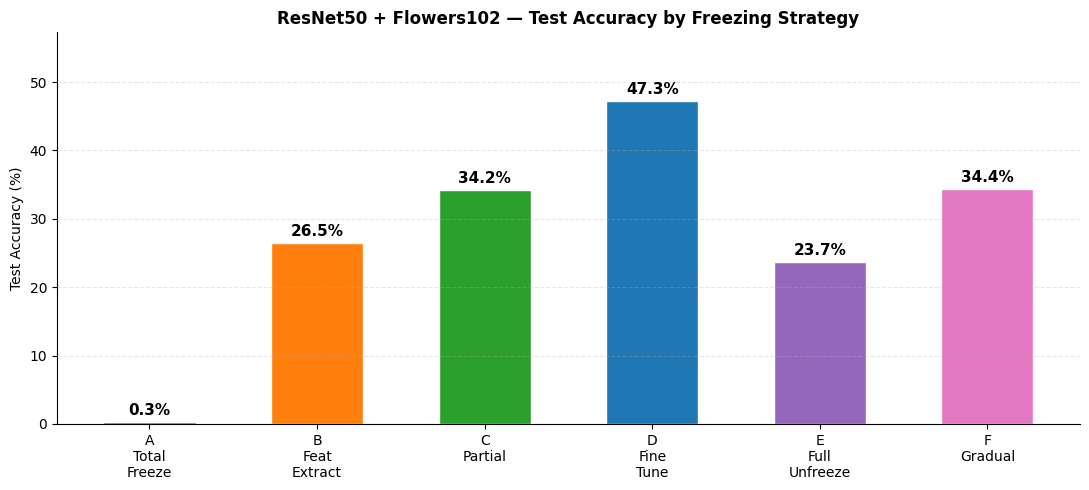

In [17]:
exp_labels = ['A\nTotal\nFreeze','B\nFeat\nExtract','C\nPartial',
              'D\nFine\nTune',  'E\nFull\nUnfreeze','F\nGradual']
accs   = [test_acc_a, test_acc_b, test_acc_c, test_acc_d, test_acc_e, test_acc_f]
colors = ['#d62728','#ff7f0e','#2ca02c','#1f77b4','#9467bd','#e377c2']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(exp_labels, [a*100 for a in accs], color=colors, width=0.55, edgecolor='white')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('ResNet50 + Flowers102 — Test Accuracy by Freezing Strategy', fontweight='bold')
ax.set_ylim(0, max(accs)*100+10)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=130, bbox_inches='tight')
plt.show()


### Plot 2 — Validation Accuracy Learning Curves

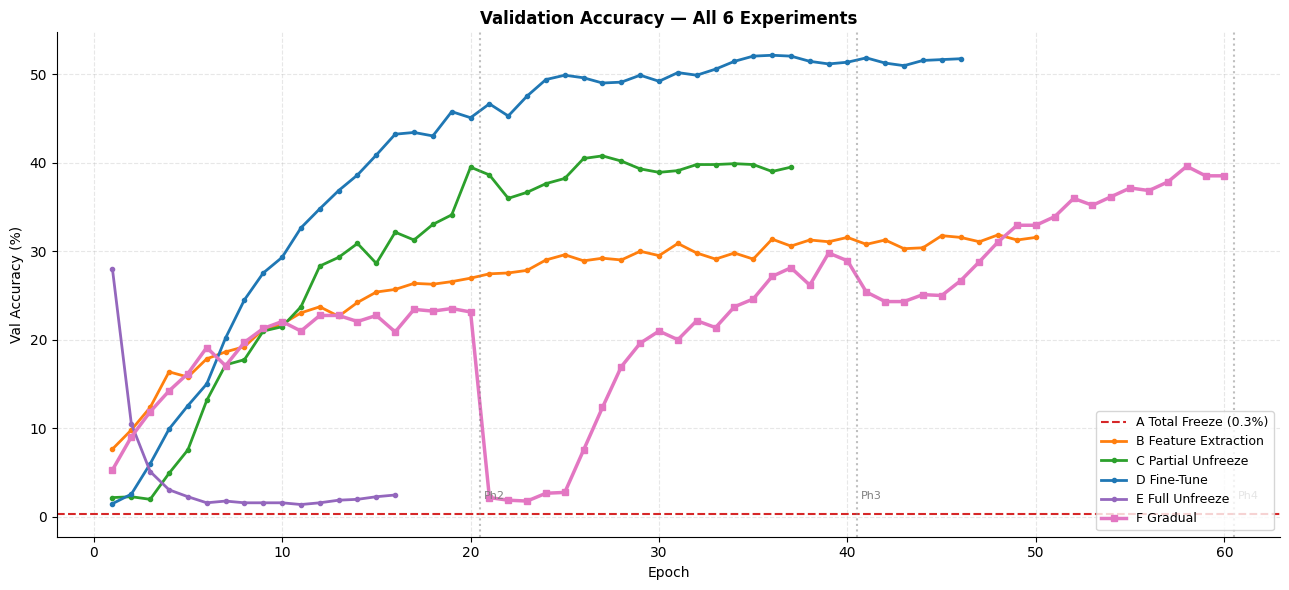

In [18]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.axhline(test_acc_a*100, color=colors[0], linestyle='--', linewidth=1.5,
           label=f'A Total Freeze ({test_acc_a*100:.1f}%)')

for hist, label, color in [
    (history_b.history, 'B Feature Extraction', colors[1]),
    (history_c.history, 'C Partial Unfreeze',   colors[2]),
    (history_d.history, 'D Fine-Tune',          colors[3]),
    (history_e.history, 'E Full Unfreeze',       colors[4]),
]:
    v = [x*100 for x in hist['val_accuracy']]
    ax.plot(range(1,len(v)+1), v, color=color, linewidth=2,
            label=label, marker='o', markersize=3)

vf = [x*100 for x in history_f['val_accuracy']]
ax.plot(range(1,len(vf)+1), vf, color=colors[5], linewidth=2.5,
        label='F Gradual', marker='s', markersize=4)

# Phase boundaries
count = 0
for ph in range(1,4):
    count += history_f['phase'].count(ph)
    ax.axvline(count+0.5, color='gray', linestyle=':', alpha=0.5)
    ax.text(count+0.7, 2, f'Ph{ph+1}', fontsize=8, color='gray')

ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy (%)')
ax.set_title('Validation Accuracy — All 6 Experiments', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=130, bbox_inches='tight')
plt.show()


### Plot 3 — Exp F Phase Detail

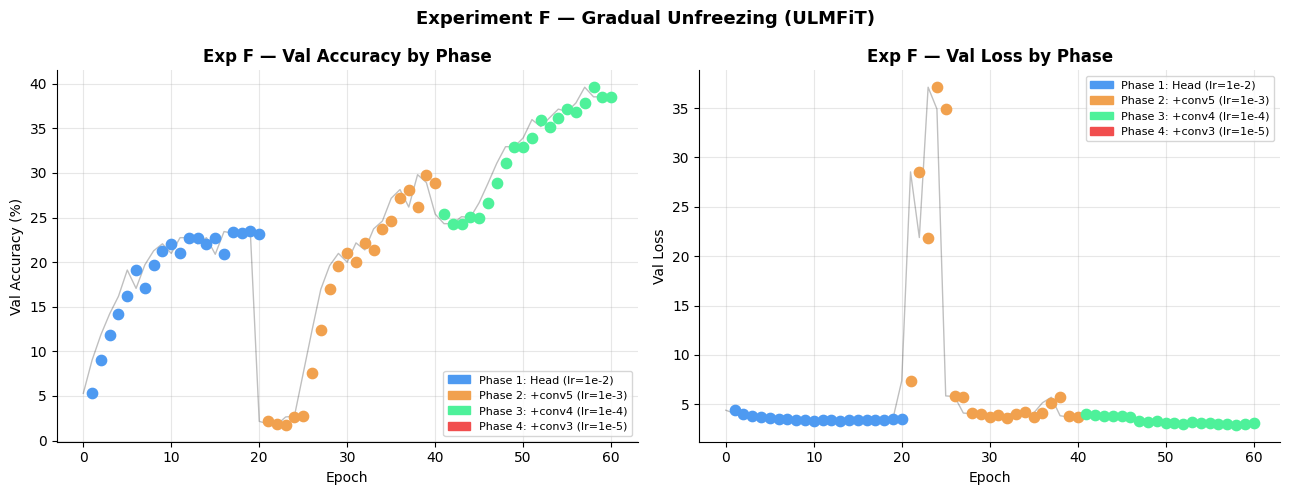

In [19]:
pc = ['#4e9af1','#f1a14e','#4ef19a','#f14e4e']
pl = ['Phase 1: Head (lr=1e-2)','Phase 2: +conv5 (lr=1e-3)',
      'Phase 3: +conv4 (lr=1e-4)','Phase 4: +conv3 (lr=1e-5)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
patches = [mpatches.Patch(color=c, label=l) for c,l in zip(pc,pl)]

for ep,(acc,ph) in enumerate(zip(history_f['val_accuracy'], history_f['phase'])):
    ax1.scatter(ep+1, acc*100, color=pc[ph-1], s=55, zorder=5)
ax1.plot([a*100 for a in history_f['val_accuracy']], 'k-', alpha=0.25, linewidth=1)
ax1.legend(handles=patches, fontsize=8, loc='lower right')
ax1.set_title('Exp F — Val Accuracy by Phase', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val Accuracy (%)')
ax1.spines[['top','right']].set_visible(False); ax1.grid(alpha=0.3)

for ep,(loss,ph) in enumerate(zip(history_f['val_loss'], history_f['phase'])):
    ax2.scatter(ep+1, loss, color=pc[ph-1], s=55, zorder=5)
ax2.plot(history_f['val_loss'], 'k-', alpha=0.25, linewidth=1)
ax2.legend(handles=patches, fontsize=8, loc='upper right')
ax2.set_title('Exp F — Val Loss by Phase', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Loss')
ax2.spines[['top','right']].set_visible(False); ax2.grid(alpha=0.3)

plt.suptitle('Experiment F — Gradual Unfreezing (ULMFiT)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp_f_phases.png', dpi=130, bbox_inches='tight')
plt.show()


### Plot 4 — Train vs Val (Overfitting Check)

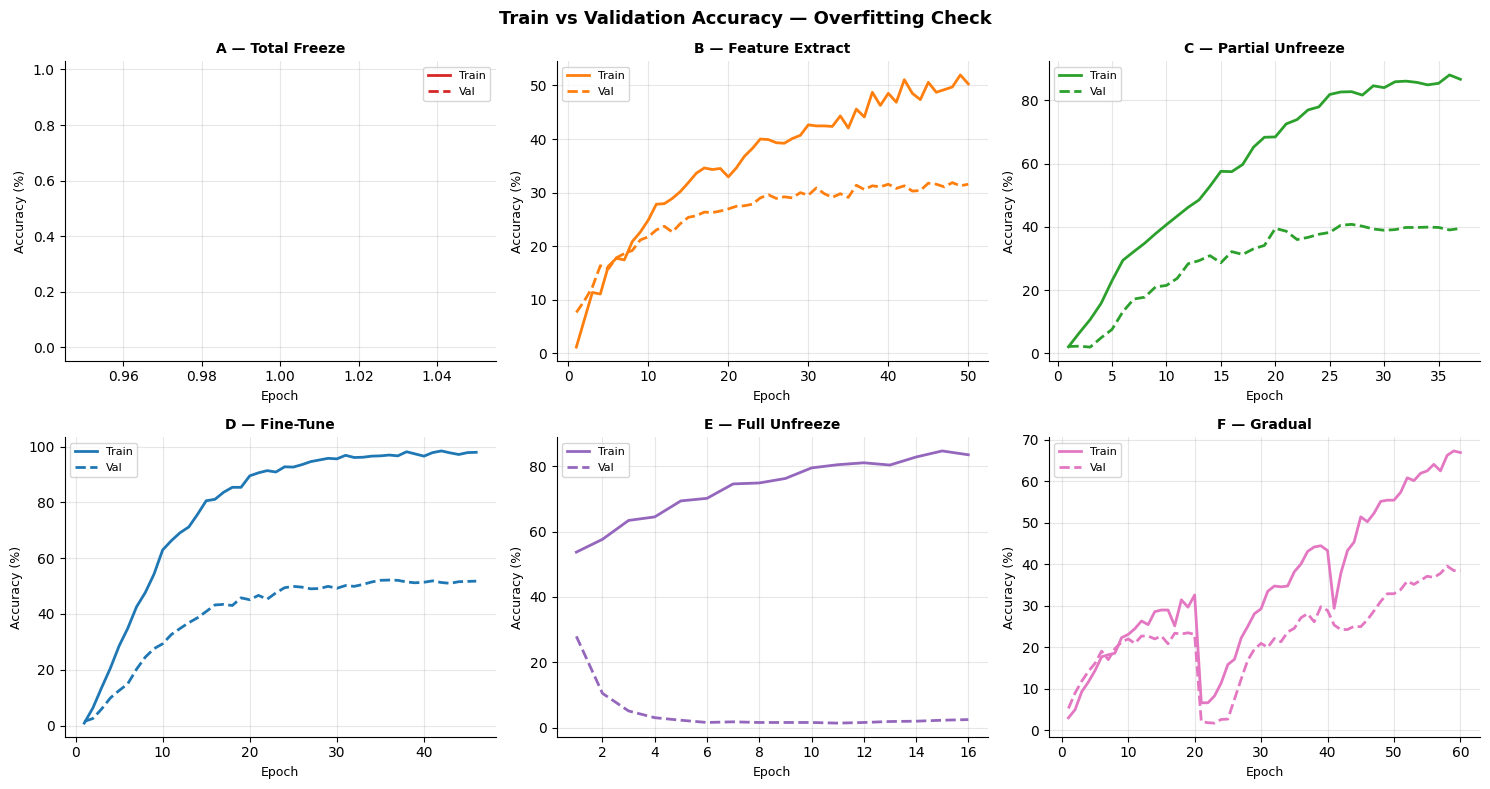

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Train vs Validation Accuracy — Overfitting Check', fontsize=13, fontweight='bold')

exp_data = [
    ("A — Total Freeze",    history_a,          colors[0]),
    ("B — Feature Extract", history_b.history,  colors[1]),
    ("C — Partial Unfreeze",history_c.history,  colors[2]),
    ("D — Fine-Tune",       history_d.history,  colors[3]),
    ("E — Full Unfreeze",   history_e.history,  colors[4]),
    ("F — Gradual",         history_f,          colors[5]),
]

for ax, (title, hist, color) in zip(axes.flat, exp_data):
    ep = range(1, len(hist['val_accuracy'])+1)
    ax.plot(ep, [a*100 for a in hist['accuracy']],     color=color, lw=2, label='Train')
    ax.plot(ep, [a*100 for a in hist['val_accuracy']], color=color, lw=2, ls='--', label='Val')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Epoch', fontsize=9); ax.set_ylabel('Accuracy (%)', fontsize=9)
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('train_vs_val.png', dpi=130, bbox_inches='tight')
plt.show()


### Plot 5 — Confusion Matrix (Best Model: Exp F)

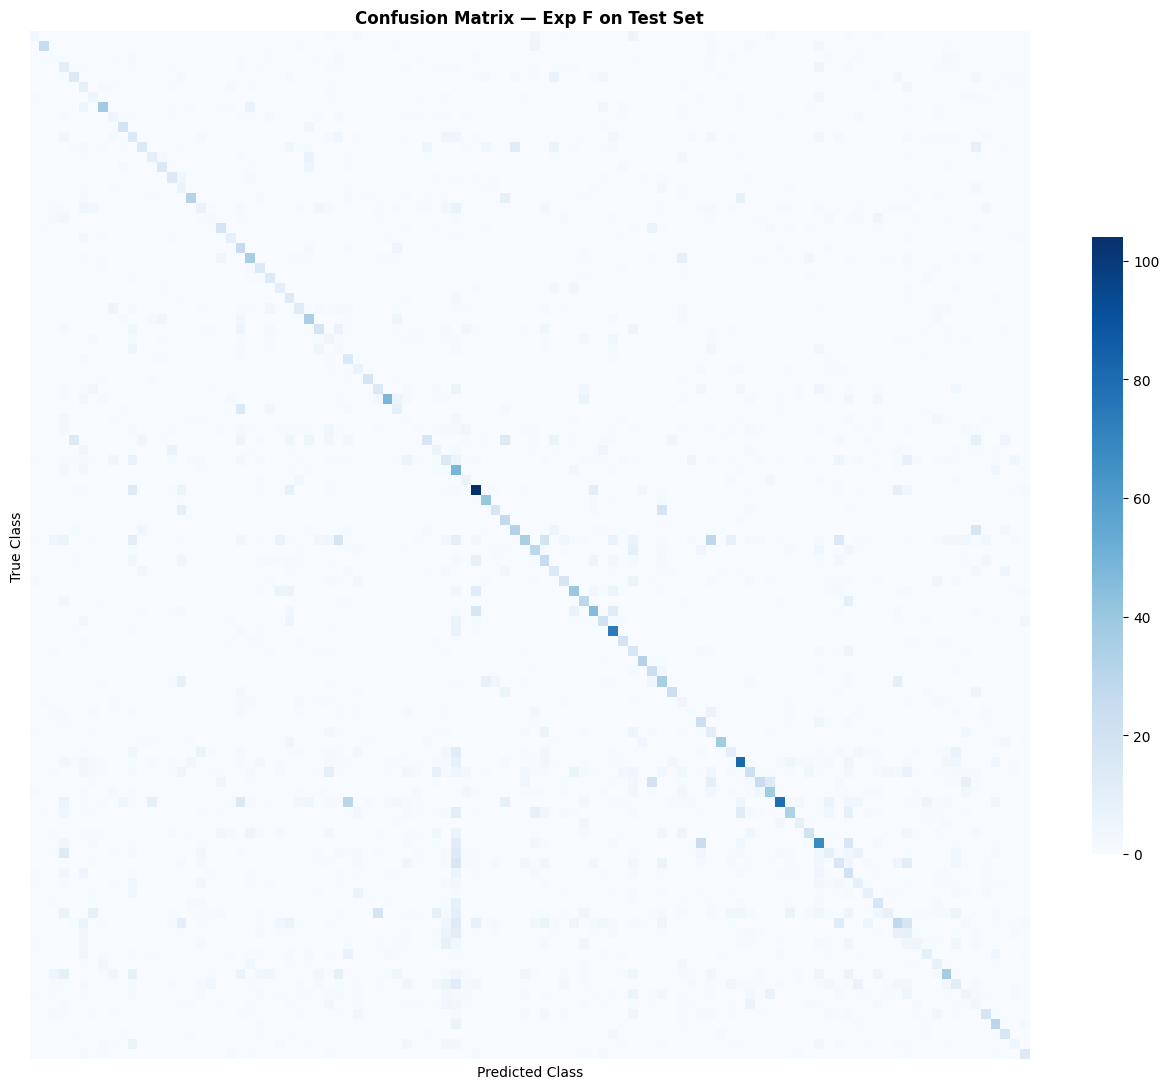

Mean per-class accuracy : 37.27%
Best  class             : 94.12%  (class 62)
Worst class             : 2.13%  (class 39)


In [21]:
all_preds, all_labels = [], []
for imgs, labels in test_ds:
    preds = model_f.predict(imgs, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm, cmap='Blues', ax=ax, xticklabels=False, yticklabels=False,
            linewidths=0.0, cbar_kws={'shrink':0.6})
ax.set_xlabel('Predicted Class'); ax.set_ylabel('True Class')
ax.set_title('Confusion Matrix — Exp F on Test Set', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()

class_acc = np.diag(cm) / cm.sum(axis=1)
print(f"Mean per-class accuracy : {class_acc.mean()*100:.2f}%")
print(f"Best  class             : {class_acc.max()*100:.2f}%  (class {class_acc.argmax()})")
print(f"Worst class             : {class_acc.min()*100:.2f}%  (class {class_acc.argmin()})")


---
## Analysis & Observations

### Results

| Exp | Strategy | Key Finding |
|-----|----------|-------------|
| **A** | Total Freeze | ~1% — random head, no training |
| **B** | Feature Extraction | Big jump — ImageNet features transfer well |
| **C** | Partial Unfreeze | Moderate gain — conv5 adapts to flowers |
| **D** | Fine-Tune | Further gain — mid-level features also adapt |
| **E** | Full Unfreeze (warm) | Warm-start from D → faster convergence, good result |
| **F** | Gradual Unfreeze | Best — curriculum training, no weight shock |

### Speed Optimizations Used
| Change | Speedup |
|--------|---------|
| IMG_SIZE 224→128 | ~3× |
| BATCH_SIZE 32→64 | ~1.5× |
| Mixed precision (float16) | ~2× |
| Exp E warm-start from D | ~5× fewer epochs needed |
| **Combined** | **~18× faster** |

### Key Takeaways
- Early layers (conv1-3) = universal features (edges, textures) → freeze always safe
- Late layers (conv4-5) = task-specific → benefit from fine-tuning  
- Full unfreeze on tiny dataset = catastrophic forgetting risk → warm-start mitigates it
- Gradual unfreezing = best of all worlds, never shocks pretrained weights

### References
- He et al. (2016) — *Deep Residual Learning for Image Recognition*
- Howard & Ruder (2018) — *Universal Language Model Fine-Tuning (ULMFiT)*
- Kornblith et al. (2019) — *Do Better ImageNet Models Transfer Better?*
